In [1]:
# ============================================================================
# PHASE 2: Feature Engineering & Preprocessing
# ============================================================================
# This notebook transforms the raw simulation data (~2.25 million values
# per case) into a compact feature matrix suitable for classification.
#
# The approach:
#   1. Load raw response data directly (NO baseline differencing)
#   2. Statistical feature extraction — compute summary statistics from
#      the raw response matrices to produce a fixed-size feature vector.
#   3. Build the final feature matrix — one row per case, ready for
#      classification.
#
# Why this alternative? The baseline-differenced approach requires
# matching each case to a perfect baseline under the same loading
# condition. The test case uses a loading condition (middle track) that
# no imperfect training case shares, causing the model to fail. By
# using raw features, the loading condition mismatch is avoided — the
# tradeoff is that loading effects are not removed, so the classifier
# must learn to separate damage from loading simultaneously.
# ============================================================================

import numpy as np
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

print("All imports loaded successfully.")

All imports loaded successfully.


In [2]:
# ============================================================================
# Set working directory and load all shared definitions from Phase 1
# ============================================================================
# Rather than redefining everything, the key variables and functions from
# the exploration notebook are recreated here: paths, FILE_MAP, TIME_STEPS,
# parse_folder_name(), load_case(), get_case_folder(), df_cases.
#
# In a typical production project these would live in src/data_loader.py and be
# imported. For now, they are repeated for notebook self-containment.
# ============================================================================

os.chdir(os.path.join(os.getcwd(), ".."))
print(f"Working directory: {os.getcwd()}")

BASE_DIR = Path("data")
PERFECT_DIR = BASE_DIR / "perfect_structure_data"
IMPERFECT_DIR = BASE_DIR / "imperfect_structure_data"
TEST_DIR = BASE_DIR / "test_set"

FILE_MAP = {
    "Deformation_X_axis.csv":  "deform_x",
    "Deformation_Y_axis.csv":  "deform_y",
    "Deformation_Z_axis.csv":  "deform_z",
    "Total Deformation.csv":   "deform_total",
    "Shear Stress XY.csv":     "stress_xy",
    "Shear Stress XZ.csv":     "stress_xz",
    "Shear Stress YZ.csv":     "stress_yz",
}

TIME_STEPS = [0.0, 0.1, 0.5, 0.9, 1.1, 1.5, 1.9, 2.1, 2.5, 2.9, 3.0]
TIME_COLS = [f"t_{t}" for t in TIME_STEPS]

def load_case(folder_path):
    """Load all 7 CSV files from a simulation case folder as a dict."""
    data = {}
    folder_path = Path(folder_path)
    for filename, short_name in FILE_MAP.items():
        filepath = folder_path / filename
        if not filepath.exists():
            print(f"  WARNING: {filename} not found in {folder_path.name}")
            continue
        df = pd.read_csv(filepath)
        if df.columns[-1].startswith("Unnamed"):
            df = df.iloc[:, :-1]
        df.columns = ["node_number"] + TIME_COLS
        df = df.set_index("node_number")
        data[short_name] = df
    return data

def parse_folder_name(name):
    """Extract structured metadata from a simulation folder name."""
    lower = name.lower()
    info = {"folder_name": name}
    if "imperfect" in lower:
        info["condition"] = "imperfect"
        match = re.search(r"imperfect_no_(\d+)", lower)
        info["imperfection_no"] = int(match.group(1)) if match else None
    else:
        info["condition"] = "perfect"
        info["imperfection_no"] = None
    info["num_trains"] = 2 if "2_trains" in lower else 1
    if "opposite_direction" in lower:
        info["track_position"] = "opposite_direction"
    elif "middle" in lower:
        info["track_position"] = "middle"
    elif "extreme" in lower:
        info["track_position"] = "extreme"
    else:
        info["track_position"] = "unknown"
    match = re.search(r"(\d+)N", name, re.IGNORECASE)
    info["load_N"] = int(match.group(1)) if match else None
    if info["condition"] == "perfect":
        info["label"] = "perfect"
    else:
        info["label"] = f"imperfect_{info['imperfection_no']}"
    return info

def get_case_folder(row):
    """Given a row from df_cases, return the full path to the case folder."""
    if row["source"] == "perfect_structure_data":
        return PERFECT_DIR / row["folder_name"]
    elif row["source"] == "imperfect_structure_data":
        return IMPERFECT_DIR / row["folder_name"]
    else:
        return TEST_DIR / row["folder_name"]

# Rebuild the cases table
records = []
for folder in sorted(PERFECT_DIR.iterdir()):
    records.append({**parse_folder_name(folder.name), "source": "perfect_structure_data"})
for folder in sorted(IMPERFECT_DIR.iterdir()):
    records.append({**parse_folder_name(folder.name), "source": "imperfect_structure_data"})
for folder in sorted(TEST_DIR.iterdir()):
    records.append({**parse_folder_name(folder.name), "source": "test_set"})

df_cases = pd.DataFrame(records)
df_cases = df_cases[["folder_name", "source", "condition", "imperfection_no",
                      "num_trains", "track_position", "load_N", "label"]]

print(f"Cases loaded: {len(df_cases)}")
print(df_cases[["folder_name", "label", "track_position", "load_N"]].to_string(index=False))

Working directory: c:\Users\Vishal Prabu\Desktop\genai-projects\structural-health-monitoring
Cases loaded: 20
                                                       folder_name       label     track_position  load_N
                      Perfect_structure_1_train_extreme_rack_5000N     perfect            extreme    5000
                     Perfect_structure_1_train_extreme_track_2000N     perfect            extreme    2000
                      Perfect_structure_1_train_middle_track_2000N     perfect             middle    2000
Perfect_structure_2_trains_opposite_direction_extreme_tracks_2000N     perfect opposite_direction    2000
                        Imperfect_no_1_1_train_extreme_track_2000N imperfect_1            extreme    2000
                        Imperfect_no_1_1_train_extreme_track_5000N imperfect_1            extreme    5000
    Imperfect_no_1_2_trains_opposite_direction_extreme_track_2000N imperfect_1 opposite_direction    2000
                        Imperfect_no_2_1_t

In [3]:
# ============================================================================
# Define matched loading condition pairs
# ============================================================================
# For baseline differencing, each imperfect case must be paired with the
# perfect case under the SAME loading condition. This isolates the damage
# effect from the loading effect.
#
# There are 3 shared loading conditions:
#   1. 1 train, extreme track, 2000N
#   2. 1 train, extreme track, 5000N
#   3. 2 trains, opposite direction, 2000N
#
# The perfect "middle track 2000N" case has no imperfect counterpart
# (only the test set uses that condition), so it is not used as a baseline.
#
# Perfect cases are assigned zero-difference vectors (they are their own
# baseline), but they still need to be included in the feature matrix
# as training samples for the "perfect" class.
# ============================================================================

PERFECT_BASELINES = {
    "extreme_2000": "Perfect_structure_1_train_extreme_track_2000N",
    "extreme_5000": "Perfect_structure_1_train_extreme_rack_5000N",
    "opposite_2000": "Perfect_structure_2_trains_opposite_direction_extreme_tracks_2000N",
    "middle_2000": "Perfect_structure_1_train_middle_track_2000N",
}

# Each imperfect case mapped to its matching loading condition key
IMPERFECT_TO_BASELINE = {
    # Imperfection 1
    "Imperfect_no_1_1_train_extreme_track_2000N": "extreme_2000",
    "Imperfect_no_1_1_train_extreme_track_5000N": "extreme_5000",
    "Imperfect_no_1_2_trains_opposite_direction_extreme_track_2000N": "opposite_2000",
    # Imperfection 2
    "Imperfect_no_2_1_train_extreme_track_2000N": "extreme_2000",
    "imperfect_no_2_1_train_extreme_Track_5000N": "extreme_5000",
    "Imperfect_no_2_2_trains_opposite_direction_Extreme_tracks_2000N": "opposite_2000",
    # Imperfection 3
    "Imperfect_no_3_1_train_extreme_track_2000N": "extreme_2000",
    "imperfect_no_3_1_train_extreme_track_5000N": "extreme_5000",
    "Imperfect_no_3_2_trains_opposite_direction_extreme_tracks_2000N": "opposite_2000",
    # Imperfection 4
    "imperfect_no_4_1_train_extreme_track_2000N": "extreme_2000",
    "imperfect_no_4_1_train_extreme_track_5000N": "extreme_5000",
    "Imperfect_no_4_2_trains_opposite_direction_extreme_tracks_2000N": "opposite_2000",
    # Imperfection 5
    "imperfect_no_5_1_train_extreme_track_2000N": "extreme_2000",
    "imperfect_no_5_1_train_extreme_track_5000N": "extreme_5000",
    "Imperfect_no_5_2_trains_opposite_direction_extreme_tracks_2000N": "opposite_2000",
}

# Test set — matched to middle_2000 baseline
TEST_TO_BASELINE = {
    "Imperfect_no_4_1_train_middle_track_2000N": "middle_2000",
}

# Verify all folder names actually exist
all_folders = set(df_cases["folder_name"].values)
print("Verification:")
for name in PERFECT_BASELINES.values():
    status = "OK" if name in all_folders else "MISSING"
    print(f"  [{ status}] {name}")
for name in IMPERFECT_TO_BASELINE.keys():
    status = "OK" if name in all_folders else "MISSING"
    print(f"  [{status}] {name}")
for name in TEST_TO_BASELINE.keys():
    status = "OK" if name in all_folders else "MISSING"
    print(f"  [{status}] {name}")

print(f"\nTotal matched pairs: {len(IMPERFECT_TO_BASELINE)} imperfect + {len(TEST_TO_BASELINE)} test")

Verification:
  [OK] Perfect_structure_1_train_extreme_track_2000N
  [OK] Perfect_structure_1_train_extreme_rack_5000N
  [OK] Perfect_structure_2_trains_opposite_direction_extreme_tracks_2000N
  [OK] Perfect_structure_1_train_middle_track_2000N
  [OK] Imperfect_no_1_1_train_extreme_track_2000N
  [OK] Imperfect_no_1_1_train_extreme_track_5000N
  [OK] Imperfect_no_1_2_trains_opposite_direction_extreme_track_2000N
  [OK] Imperfect_no_2_1_train_extreme_track_2000N
  [OK] imperfect_no_2_1_train_extreme_Track_5000N
  [OK] Imperfect_no_2_2_trains_opposite_direction_Extreme_tracks_2000N
  [OK] Imperfect_no_3_1_train_extreme_track_2000N
  [OK] imperfect_no_3_1_train_extreme_track_5000N
  [OK] Imperfect_no_3_2_trains_opposite_direction_extreme_tracks_2000N
  [OK] imperfect_no_4_1_train_extreme_track_2000N
  [OK] imperfect_no_4_1_train_extreme_track_5000N
  [OK] Imperfect_no_4_2_trains_opposite_direction_extreme_tracks_2000N
  [OK] imperfect_no_5_1_train_extreme_track_2000N
  [OK] imperfect_no_5_

In [5]:
# ============================================================================
# Compute baseline differences for all cases
# ============================================================================
# For each imperfect case:
#   1. Load the imperfect case data (7 quantities)
#   2. Load the matched perfect baseline data (same loading condition)
#   3. Find common nodes (present in both)
#   4. Compute: difference = imperfect - perfect at each common node
#
# For each perfect case:
#   The difference is zero by definition (it IS the baseline), so a
#   zero-valued DataFrame with the same shape is created.
#
# The result is stored in a dict: case_differences[folder_name] = {
#     "deform_x": DataFrame of differences (common_nodes × 11 time steps),
#     "deform_y": ..., etc.
# }
# ============================================================================

# Pre-load all perfect baselines (avoids reloading them for every imperfect case)
perfect_data_cache = {}
for key, folder_name in PERFECT_BASELINES.items():
    folder = PERFECT_DIR / folder_name
    perfect_data_cache[key] = load_case(folder)
    print(f"  Cached baseline: {key} ({folder_name})")

# Load raw response data for all 20 cases (no baseline subtraction)

case_raw_data = {}
case_labels = {}

for idx, row in df_cases.iterrows():
    folder = get_case_folder(row)
    case_data = load_case(folder)
    case_raw_data[row["folder_name"]] = case_data
    case_labels[row["folder_name"]] = row["label"]
    print(f"  Loaded: {row['folder_name']} ({case_data['deform_x'].shape[0]} nodes)")

print(f"\nTotal cases loaded: {len(case_raw_data)}")

  Cached baseline: extreme_2000 (Perfect_structure_1_train_extreme_track_2000N)
  Cached baseline: extreme_5000 (Perfect_structure_1_train_extreme_rack_5000N)
  Cached baseline: opposite_2000 (Perfect_structure_2_trains_opposite_direction_extreme_tracks_2000N)
  Cached baseline: middle_2000 (Perfect_structure_1_train_middle_track_2000N)
  Loaded: Perfect_structure_1_train_extreme_rack_5000N (29226 nodes)
  Loaded: Perfect_structure_1_train_extreme_track_2000N (29226 nodes)
  Loaded: Perfect_structure_1_train_middle_track_2000N (29226 nodes)
  Loaded: Perfect_structure_2_trains_opposite_direction_extreme_tracks_2000N (29226 nodes)
  Loaded: Imperfect_no_1_1_train_extreme_track_2000N (28902 nodes)
  Loaded: Imperfect_no_1_1_train_extreme_track_5000N (28902 nodes)
  Loaded: Imperfect_no_1_2_trains_opposite_direction_extreme_track_2000N (28902 nodes)
  Loaded: Imperfect_no_2_1_train_extreme_track_2000N (28794 nodes)
  Loaded: imperfect_no_2_1_train_extreme_Track_5000N (28794 nodes)
  Loade

In [6]:
# ============================================================================
# Extract statistical features from difference matrices
# ============================================================================
# Each case now has 7 difference matrices (one per quantity), each of shape
# (common_nodes × 11 time steps). These need to be compressed into a
# fixed-size feature vector per case.
#
# This is PER CASE:
# For each quantity, the following statistics are computed:
#
#   Across ALL nodes and ALL time steps (global):
#     mean, std, absmax, rms
#
#   Across all nodes at EACH time step (temporal profile):
#     mean, std, absmax, rms at each of the 11 time steps
#
# This produces per quantity:
#   4 global stats + (11 × 4) temporal stats = 48 features
#
# Across 7 quantities: 48 × 7 = 336 features per case.
#
# Additionally, the node count difference (perfect - imperfect) is
# NOT included as a feature (see Phase 1 discussion on why).
# ============================================================================

def extract_features(diff_dict):
    """
    Extract a flat feature vector from a case's difference dictionary.
    
    Input: dict of 7 DataFrames (qty_name -> DataFrame of differences)
    Output: dict of feature_name -> value
    """
    features = {}
    
    for qty_name, df_diff in diff_dict.items():
        values = df_diff.values  # shape: (n_nodes, 11)
        
        # --- Global statistics (across all nodes and time steps) ---
        features[f"{qty_name}_global_mean"] = np.mean(values)
        features[f"{qty_name}_global_std"] = np.std(values)
        features[f"{qty_name}_global_absmax"] = np.max(np.abs(values))
        features[f"{qty_name}_global_rms"] = np.sqrt(np.mean(values ** 2))
        
        # --- Per-timestep statistics (across all nodes at each time step) ---
        for t_idx, t_col in enumerate(TIME_COLS):
            col_values = df_diff[t_col].values
            features[f"{qty_name}_{t_col}_mean"] = np.mean(col_values)
            features[f"{qty_name}_{t_col}_std"] = np.std(col_values)
            features[f"{qty_name}_{t_col}_absmax"] = np.max(np.abs(col_values))
            features[f"{qty_name}_{t_col}_rms"] = np.sqrt(np.mean(col_values ** 2))
    
    return features

feature_records = []

for folder_name, raw_dict in case_raw_data.items():
    features = extract_features(raw_dict)
    features["folder_name"] = folder_name
    features["label"] = case_labels[folder_name]
    feature_records.append(features)

df_features_raw = pd.DataFrame(feature_records)

meta_cols = ["folder_name", "label"]
feature_cols = [c for c in df_features_raw.columns if c not in meta_cols]

print(f"Feature matrix shape: {df_features_raw.shape}")
print(f"  Cases (rows): {len(df_features_raw)}")
print(f"  Features (columns): {len(feature_cols)}")

Feature matrix shape: (20, 338)
  Cases (rows): 20
  Features (columns): 336


In [8]:
# ============================================================================
# Normalise features and save the final feature matrix
# ============================================================================
# The 336 features span very different scales — deformation differences
# are in mm (order 10⁻⁵ to 10⁻²) while stress differences are in MPa
# (different order entirely). Without normalisation, features with larger
# magnitudes would dominate the classifier's decision.
#
# StandardScaler is used: for each feature, subtract the mean and divide
# by the standard deviation, producing zero-mean unit-variance features.
#
# !! IMPORTANT: the scaler is fitted on TRAINING data only (19 cases). The
# test case is transformed using the training statistics, never included
# in the fit. This prevents data leakage. !!
#
# The final outputs are:
#   - X_train: (19, 336) normalised feature matrix
#   - y_train: (19,) label array
#   - X_test:  (1, 336) normalised feature vector for the test case
#   - y_test:  (1,) ground truth label for validation
#   - Feature matrix saved to data/feature_matrix.csv for reuse in Phase 3
#
# This is NOT the final scaling — Phase 3 will apply its own scaler
# as part of the model pipeline (fitted per cross-validation fold).
# The raw (un-normalised) feature matrix is what gets saved to disk,
# since normalisation must be recomputed for each train/test split.
# ============================================================================

from sklearn.preprocessing import StandardScaler, LabelEncoder

# Split into train and test
test_folder_name = "Imperfect_no_4_1_train_middle_track_2000N"
df_train = df_features_raw[df_features_raw["folder_name"] != test_folder_name].copy()
df_test = df_features_raw[df_features_raw["folder_name"] == test_folder_name].copy()

print(f"Training set: {len(df_train)} cases")
print(f"Test set: {len(df_test)} cases")

# Separate features and labels
X_train_raw = df_train[feature_cols].values
X_test_raw = df_test[feature_cols].values
y_train_str = df_train["label"].values
y_test_str = df_test["label"].values

# Encode labels as integers
le = LabelEncoder()
le.fit(sorted(df_train["label"].unique()))
y_train = le.transform(y_train_str)
y_test = le.transform(y_test_str)

print(f"\nLabel encoding:")
for i, label in enumerate(le.classes_):
    count = np.sum(y_train == i)
    print(f"  {i} → {label} ({count} training samples)")

# Normalise features (fit on training data only)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"\nFeature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  y_test:  {y_test.shape}")

# Verify: perfect cases should have similar scaled values (all were zero before scaling)
perfect_mask = y_train_str == "perfect"
print(f"\nSanity check — mean of scaled features for perfect cases: {X_train[perfect_mask].mean():.4f}")
# for above, non zero since: The perfect cases are zero in the raw (unscaled) features. But StandardScaler subtracts the mean 
# and divides by the standard deviation of the entire training set (which includes both perfect and imperfect cases).
print(f"Sanity check — mean of scaled features for imperfect cases: {X_train[~perfect_mask].mean():.4f}")

# Save the full feature matrix (with labels and folder names) for Phase 3 - The raw values are saved
# The raw (pre-normalization) values are saved because normalization should always be recomputed from scratch 
# when training a model. If we saved the normalized values and later changed the train/test split (say during cross-validation), 
# the scaling would be wrong
df_features_raw.to_csv("data/feature_matrix_raw.csv", index=False)
print(f"Feature matrix saved to data/feature_matrix_raw.csv")

Training set: 19 cases
Test set: 1 cases

Label encoding:
  0 → imperfect_1 (3 training samples)
  1 → imperfect_2 (3 training samples)
  2 → imperfect_3 (3 training samples)
  3 → imperfect_4 (3 training samples)
  4 → imperfect_5 (3 training samples)
  5 → perfect (4 training samples)

Feature matrix shapes:
  X_train: (19, 336)
  X_test:  (1, 336)
  y_train: (19,)
  y_test:  (1,)

Sanity check — mean of scaled features for perfect cases: -0.1963
Sanity check — mean of scaled features for imperfect cases: 0.0523
Feature matrix saved to data/feature_matrix_raw.csv


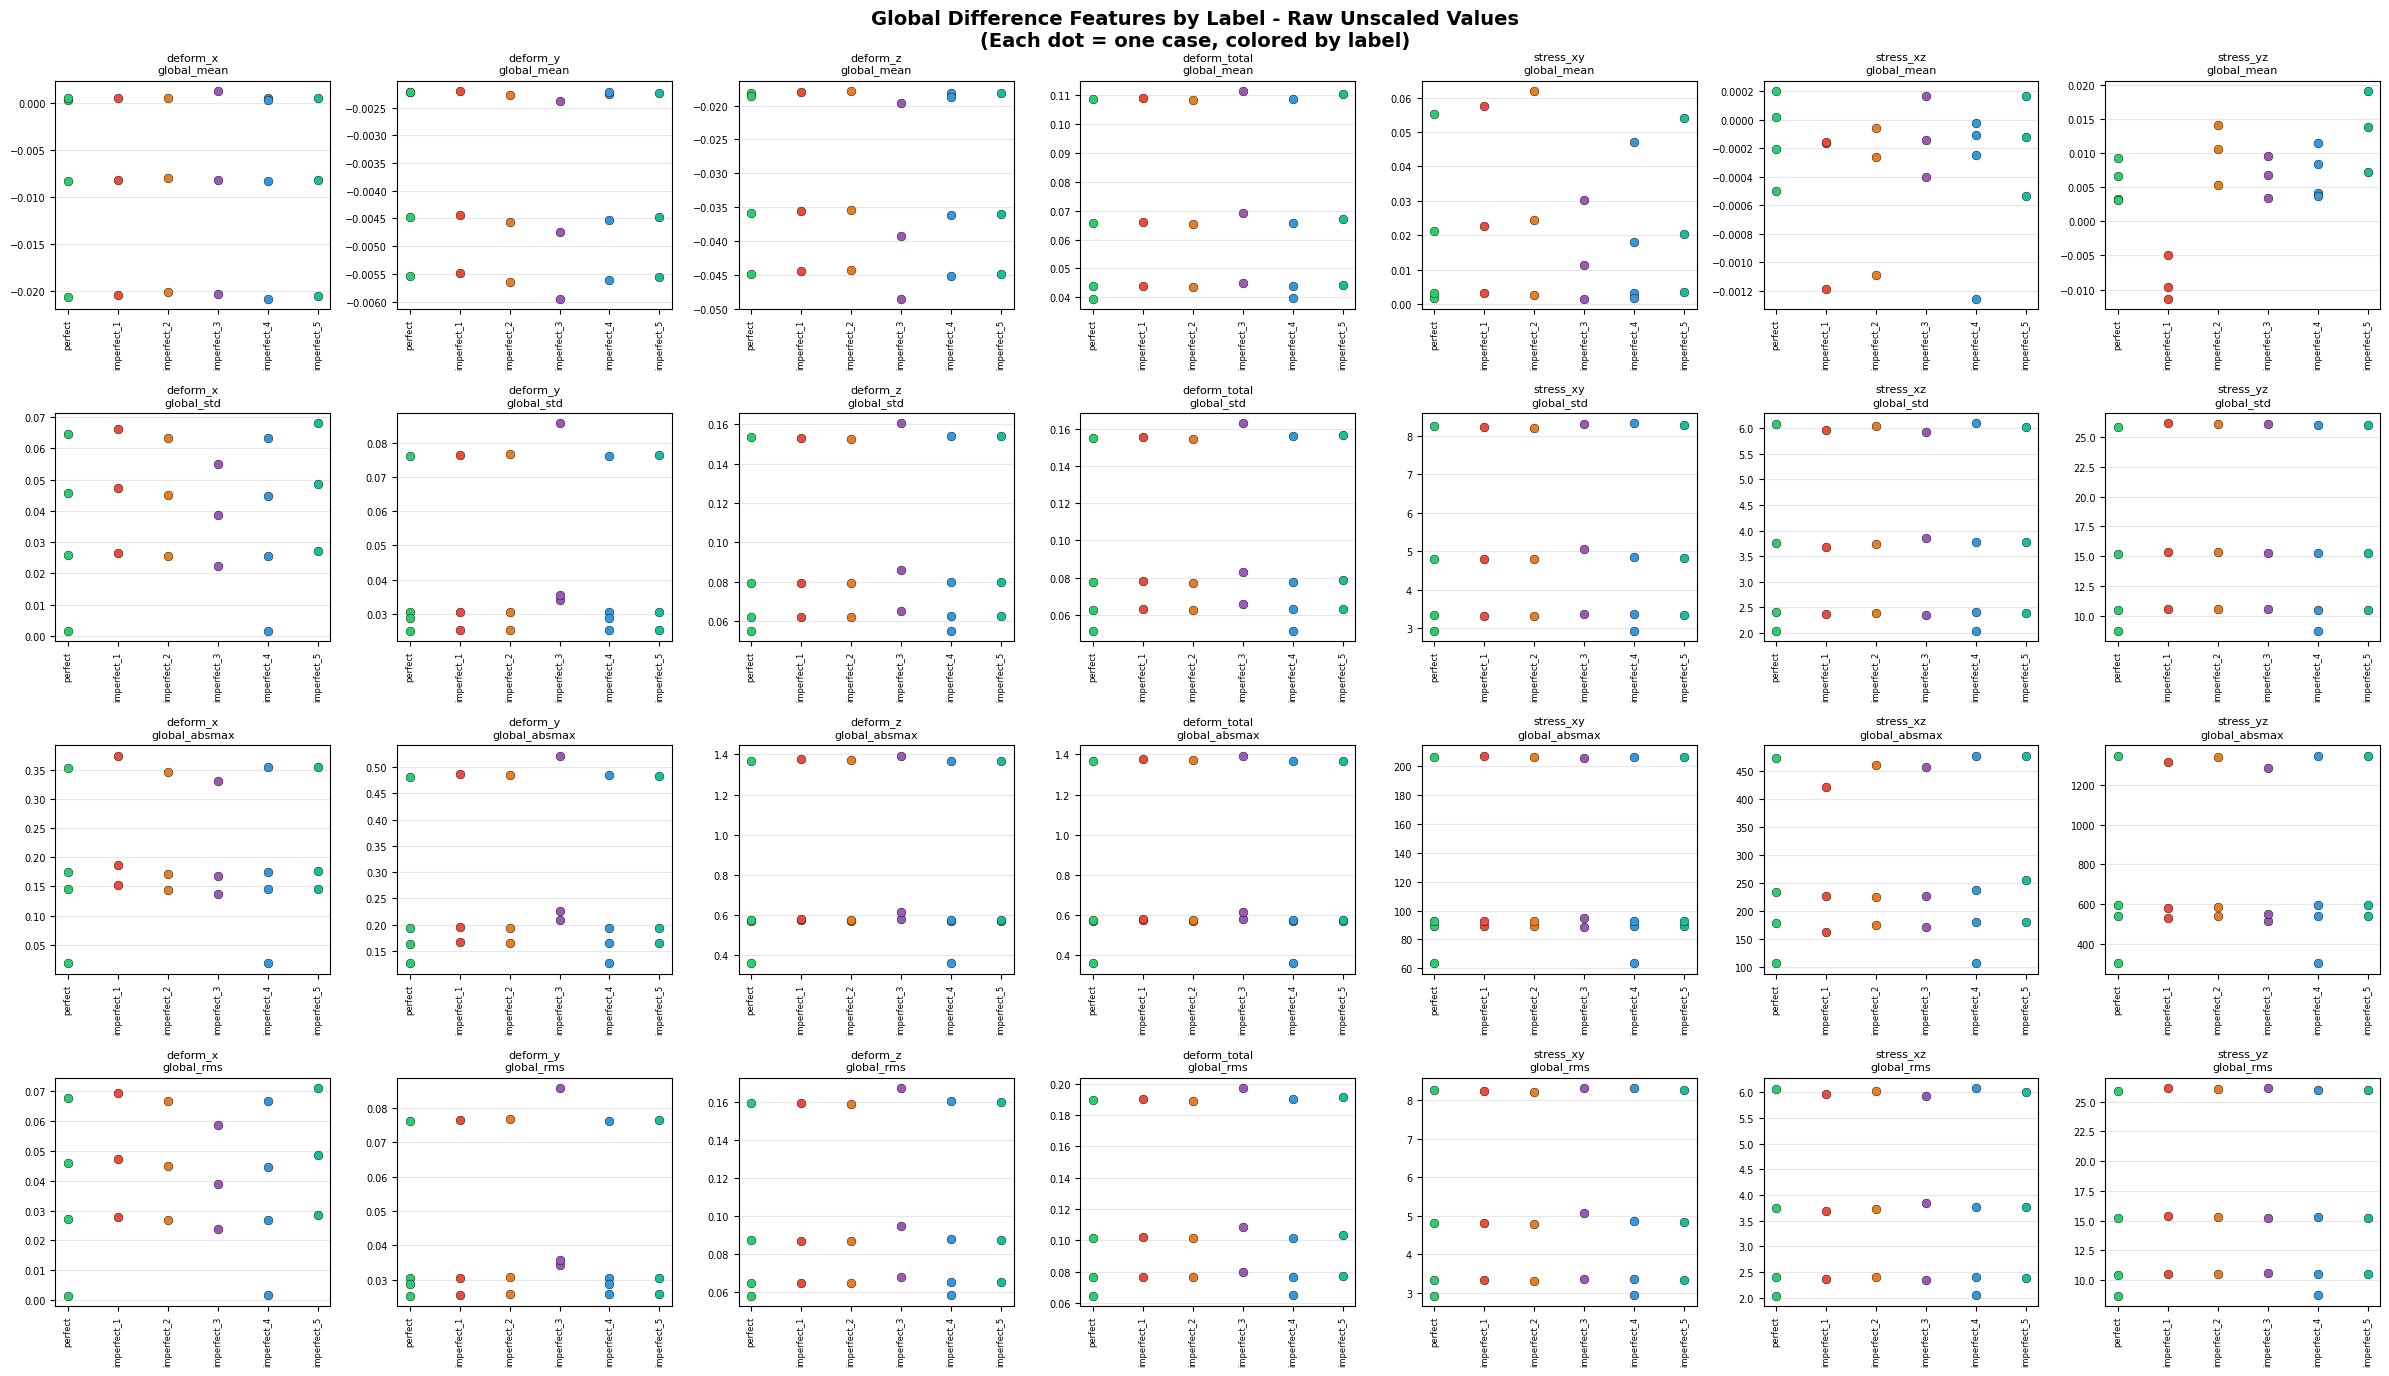

Figure saved to results/10_global_features_by_label_raw.png


In [11]:
# ============================================================================
# Visualise global features across cases
# ============================================================================
# A quick look at the 4 global statistics (mean, std, absmax, rms) for
# each of the 7 quantities, plotted per case and colored by label.
# This shows whether the extracted features separate the classes.
#
# Only the 28 global features are plotted here (4 stats × 7 quantities).
# The remaining 308 per-timestep features follow similar patterns.
# ============================================================================

global_stats = ["global_mean", "global_std", "global_absmax", "global_rms"]
qty_names = list(FILE_MAP.values())

palette = {
    "perfect": "#2ecc71",
    "imperfect_1": "#e74c3c",
    "imperfect_2": "#e67e22",
    "imperfect_3": "#9b59b6",
    "imperfect_4": "#3498db",
    "imperfect_5": "#1abc9c",
}

fig, axes = plt.subplots(4, 7, figsize=(24, 14))
fig.suptitle("Global Difference Features by Label - Raw Unscaled Values\n(Each dot = one case, colored by label)",
             fontsize=14, fontweight="bold")

for i, stat in enumerate(global_stats):
    for j, qty in enumerate(qty_names):
        col_name = f"{qty}_{stat}"
        ax = axes[i, j]
        
        for label, color in palette.items():
            mask = df_features_raw["label"] == label
            vals = df_features_raw.loc[mask, col_name]
            ax.scatter([label] * len(vals), vals, c=color, s=40,
                       edgecolors="black", linewidth=0.3, zorder=3)
        
        ax.set_title(f"{qty}\n{stat}", fontsize=8)
        ax.tick_params(axis="x", rotation=90, labelsize=6)
        ax.tick_params(axis="y", labelsize=7)
        ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("results/10_global_features_by_label_raw.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to results/10_global_features_by_label_raw.png")